# GCI World 2026 April — Final Assignment

## 1. Setup & Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.multitest import multipletests

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, roc_auc_score, roc_curve, precision_recall_curve,
    average_precision_score, classification_report, confusion_matrix,
    brier_score_loss
)
from sklearn.calibration import calibration_curve
from sklearn.inspection import permutation_importance

PALETTE = {
    'stay':   '#0B7285', 
    'churn':  '#C1121F',  
    'neutral':'#495057',
    'accent': '#F2A541',   
    'grid':   '#DEE2E6',
}
sns.set_style('whitegrid', {'grid.color': PALETTE['grid']})
plt.rcParams.update({
    'figure.dpi': 110,
    'font.size': 11,
    'axes.edgecolor': PALETTE['neutral'],
    'axes.labelcolor': PALETTE['neutral'],
    'text.color': PALETTE['neutral'],
})

RANDOM_STATE = 42
ALPHA = 0.05 

## 2. Data Loading & Dataset Merging

The dataset consists of two files. **`Record.csv`** contains monthly customer usage behavior (minutes, revenue, calls, etc.) along with the `churn` label. **`Client.csv`** — customer demographic attributes and device profiles.

Both are merged via `Customer_ID` using an `inner join`, as we only require customers with complete data from both sources for modeling.

In [2]:
BASE_PATH = ''  # isi dengan path folder Anda jika file tidak berada di direktori kerja

client = pd.read_csv(BASE_PATH + 'Client.csv')
record = pd.read_csv(BASE_PATH + 'Record.csv')

print(f'Client dataset : {client.shape[0]:,} baris x {client.shape[1]} kolom')
print(f'Record dataset : {record.shape[0]:,} baris x {record.shape[1]} kolom')

Client dataset : 100,000 baris x 50 kolom
Record dataset : 100,000 baris x 51 kolom


In [3]:
df = pd.merge(record, client, on='Customer_ID', how='inner')
df.head(3)

,rev_Mean,mou_Mean,totmrc_Mean,da_Mean,ovrmou_Mean,ovrrev_Mean,vceovr_Mean,datovr_Mean,roam_Mean,change_mou,...,dwllsize,forgntvl,ethnic,kid0_2,kid3_5,kid6_10,kid11_15,kid16_17,creditcd,eqpdays
0,23.9975,219.25,22.500,0.2475,0.00,0.0,0.0,0.0,0.0,-157.25,...,A,0.0,N,U,U,U,U,U,Y,361.0
1,57.4925,482.75,37.425,0.2475,22.75,9.1,9.1,0.0,0.0,532.25,...,A,0.0,Z,U,U,U,U,U,Y,240.0
2,16.9900,10.25,16.990,0.0000,0.00,0.0,0.0,0.0,0.0,-4.25,...,A,0.0,N,U,Y,U,U,U,Y,1504.0


## 3. Data Quality Check

Before proceeding to EDA, we need to determine three things: whether there are duplicate rows, the proportion of missing values ​​per column, and the composition of data types. This informs the imputation strategy and determines which columns are worth retaining.

In [4]:
n_dup = df.duplicated(subset='Customer_ID').sum()
print(f'Duplicate rows based on Customer_ID : {n_dup}')
print(f'Data type:\n{df.dtypes.value_counts()}')

Duplicate rows based on Customer_ID : 0
Data type:
float64    69
object     21
int64      10
Name: count, dtype: int64


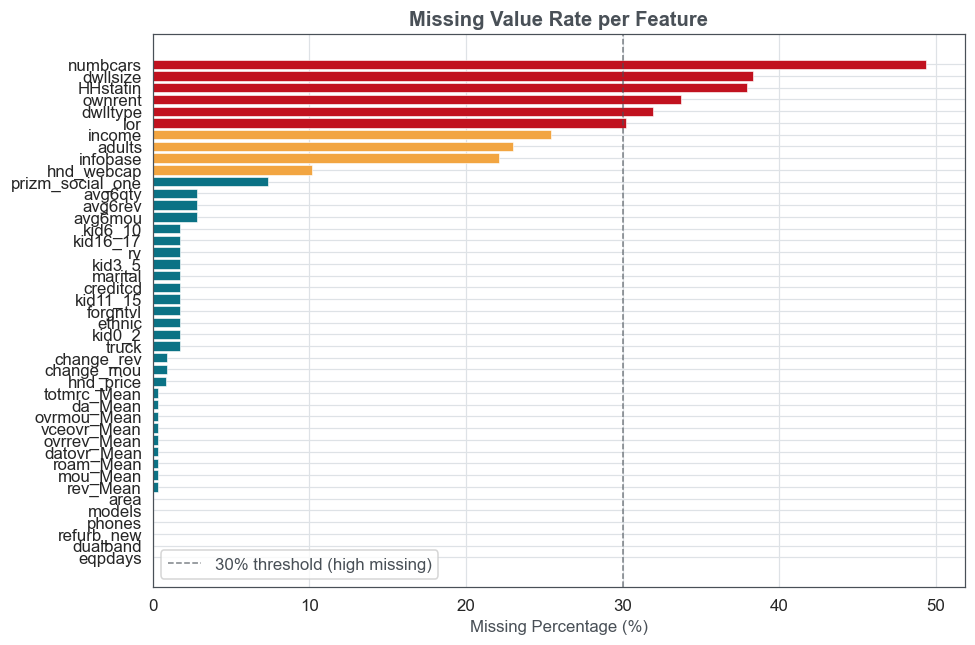

Features with missing > 30% (candidates discarded): ['numbcars', 'dwllsize', 'HHstatin', 'ownrent', 'dwlltype', 'lor']


In [5]:
miss = (df.isnull().mean() * 100).sort_values(ascending=False)
miss = miss[miss > 0]

fig, ax = plt.subplots(figsize=(9, 6))
colors = [PALETTE['churn'] if v > 30 else PALETTE['accent'] if v > 10 else PALETTE['stay'] for v in miss.values]
ax.barh(miss.index[::-1], miss.values[::-1], color=colors[::-1], edgecolor='white', linewidth=0.4)
ax.axvline(30, color=PALETTE['neutral'], linestyle='--', linewidth=1, alpha=0.7, label='30% threshold (high missing)')
ax.set_xlabel('Missing Percentage (%)')
ax.set_title('Missing Value Rate per Feature', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

high_missing = miss[miss > 30].index.tolist()
print(f'Features with missing > 30% (candidates discarded): {high_missing}')

Columns like `numbcars`, `dwllsize`, `HHstatin`, `ownrent`, `dwlltype`, and `lor` exhibit missing rates exceeding 30%; the majority of these are demographic data derived from third-party appends, which are commonly incomplete.

Due to the high proportion of missing values ​​and the fact that they are not core behavioral features, these columns will be **dropped** rather than forcibly imputed (imputing data with >30% missing values ​​risks introducing disproportionate bias into the model). Numerical features with low missing rates (<3%, e.g., `avg6mou`, `change_mou`) will be imputed using the median within the `Pipeline` to prevent information leakage from the test set to the training set.

## 4. In-depth Exploratory Data Analysis (EDA)

The EDA approach here goes beyond mere visualization. Any patterns observed in the charts will be **statistically tested** to ensure the differences are real (significant) rather than just random fluctuations. Given the sample size of n = 100,000, significance testing alone is insufficient therefore, we also calculate the **effect size** to assess practical relevance.


### 4.1 Distribution of the Target Variable (Churn)

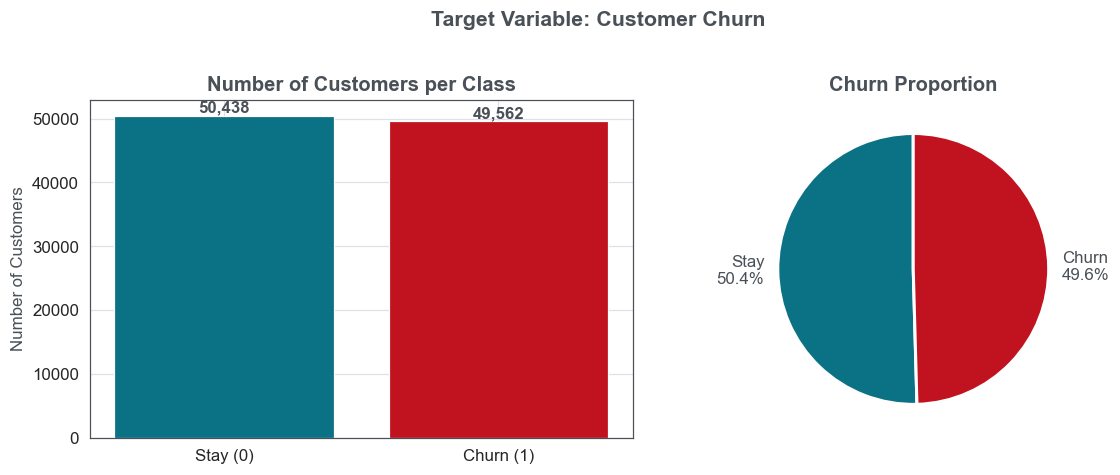

Observation churn rate : 49.56%
Classes are relatively balanced (~50/50) — not a case of imbalanced classification, so accuracy & AUC-ROC are both reliable as metrics.


In [6]:
churn_counts = df['churn'].value_counts().sort_index()
churn_pct = df['churn'].value_counts(normalize=True).sort_index() * 100

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

axes[0].bar(['Stay (0)', 'Churn (1)'], churn_counts.values,
            color=[PALETTE['stay'], PALETTE['churn']], edgecolor='white', linewidth=0.8)
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')
axes[0].set_title('Number of Customers per Class', fontweight='bold')
axes[0].set_ylabel('Number of Customers')

axes[1].pie(churn_counts.values,
            labels=[f'Stay\n{churn_pct[0]:.1f}%', f'Churn\n{churn_pct[1]:.1f}%'],
            colors=[PALETTE['stay'], PALETTE['churn']],
            wedgeprops={'edgecolor': 'white', 'linewidth': 2}, startangle=90)
axes[1].set_title('Churn Proportion', fontweight='bold')

plt.suptitle('Target Variable: Customer Churn', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"Observation churn rate : {churn_pct[1]:.2f}%")
print('Classes are relatively balanced (~50/50) — not a case of imbalanced classification, so accuracy & AUC-ROC are both reliable as metrics.')

A churn rate of **~49.6%** is indeed well above the industry benchmark (20–35%), but technically, the target classes are quite balanced (50/50). This is significant that it means we do not need *class imbalance* handling techniques (SMOTE, class weighting, etc.), and simple metrics like accuracy remain informative—though AUC-ROC is still chosen as the primary metric because it measures the model's ability to rank risk across all thresholds, rather than just at a single 0.5 cutoff point.

### 4.2 Statistical Tests Numerical Features vs Churn

For each key numerical feature, we compare the distributions between *staying* and *churning* customers using:
- **Mann-Whitney U test** — chosen over the t-test because many features (e.g., revenue, usage minutes) are right-skewed and not normally distributed (the t-test assumes normality, whereas the Mann-Whitney test does not).
- **Rank-biserial correlation (r)** as an effect size measure — quantifying the magnitude and consistency of the difference between the two groups, independent of statistical significance.
- **Bonferroni correction** for multiple testing, as testing multiple features simultaneously increases the risk of false positives.

In [7]:
candidate_features = {
    'rev_Mean': 'Average Monthly Revenue',
    'mou_Mean': 'Monthly Minutes of Use',
    'change_mou': 'Change in Minutes of Use (MoU)',
    'change_rev': 'Change in Revenue',
    'custcare_Mean': 'Calls to Customer Care',
    'drop_vce_Mean': 'Dropped Calls',
    'months': 'Subscription Duration (months)',
    'eqpdays': 'Device Age (days)',
    'totrev': 'Total Historical Revenue',
    'hnd_price': 'Device Price',
    'income': 'Estimated Income',
    'retdays': 'Days since Last Retention',
}
candidate_features = {k: v for k, v in candidate_features.items() if k in df.columns}

rows = []
for col, label in candidate_features.items():
    stay = df.loc[df['churn'] == 0, col].dropna()
    churn = df.loc[df['churn'] == 1, col].dropna()
    u_stat, p_val = stats.mannwhitneyu(churn, stay, alternative='two-sided')
    n1, n2 = len(churn), len(stay)
    rank_biserial = 1 - (2 * u_stat) / (n1 * n2)  # Mann-Whitney effect size
    rows.append({
        'Feature': label, 'column': col,
        'Median Stay': stay.median(), 'Median Churn': churn.median(),
        'p-value': p_val, 'effect_size_r': rank_biserial,
    })

stat_table = pd.DataFrame(rows)
reject, p_adj, _, _ = multipletests(stat_table['p-value'], alpha=ALPHA, method='bonferroni')
stat_table['p-value (Bonferroni)'] = p_adj
stat_table['Significant'] = reject
stat_table['|effect size|'] = stat_table['effect_size_r'].abs()
stat_table = stat_table.sort_values('|effect size|', ascending=False)

display_cols = ['Feature', 'Median Stay', 'Median Churn', 'p-value (Bonferroni)', 'effect_size_r', 'Significant']
pd.set_option('display.float_format', lambda x: f'{x:.4g}')
stat_table[display_cols].reset_index(drop=True)

,Feature,Median Stay,Median Churn,p-value (Bonferroni),effect_size_r,Significant
0,Device Age (days),310,366,0,-0.148,True
1,Device Price,130,99.99,2.586e-228,0.1169,True
2,Monthly Minutes of Use,380.5,329.8,2.511e-102,0.07898,True
3,Change in Minutes of Use (MoU),-3,-10,6.664e-58,0.05938,True
4,Calls to Customer Care,0,0,6.544e-69,0.0587,True
5,Subscription Duration (months),16,17,1.784e-42,-0.05047,True
6,Total Historical Revenue,784.4,823.7,5.106e-26,-0.03934,True
7,Average Monthly Revenue,48.88,47.49,1.742e-15,0.03018,True
8,Dropped Calls,3,3,1.295e-12,0.02703,True
9,Change in Revenue,-0.2925,-0.315,0.1166,0.009369,False


`effect_size_r` ranges from -1 to 1: values ​​close to 0 indicate that the distributions for *stay* and *churn* customers are virtually indistinguishable, while values ​​further from 0 (whether positive or negative) signify a substantial and consistent difference. The `Signifikan` column accounts for the Bonferroni correction, ensuring protection against false conclusions arising from repeated testing.

The features with the largest `|effect size|` are the ones that statistically **best distinguish** between churned and retained customers—meaning the difference is not merely visible in a histogram but is statistically validated. The following section examines these high-impact features individually.

### 4.3 Distribution of Features with the Largest Effects

We visualize the top six features from the statistical test table above to clearly show the direction and shape of the differences—while also visually confirming what the figures already indicate.

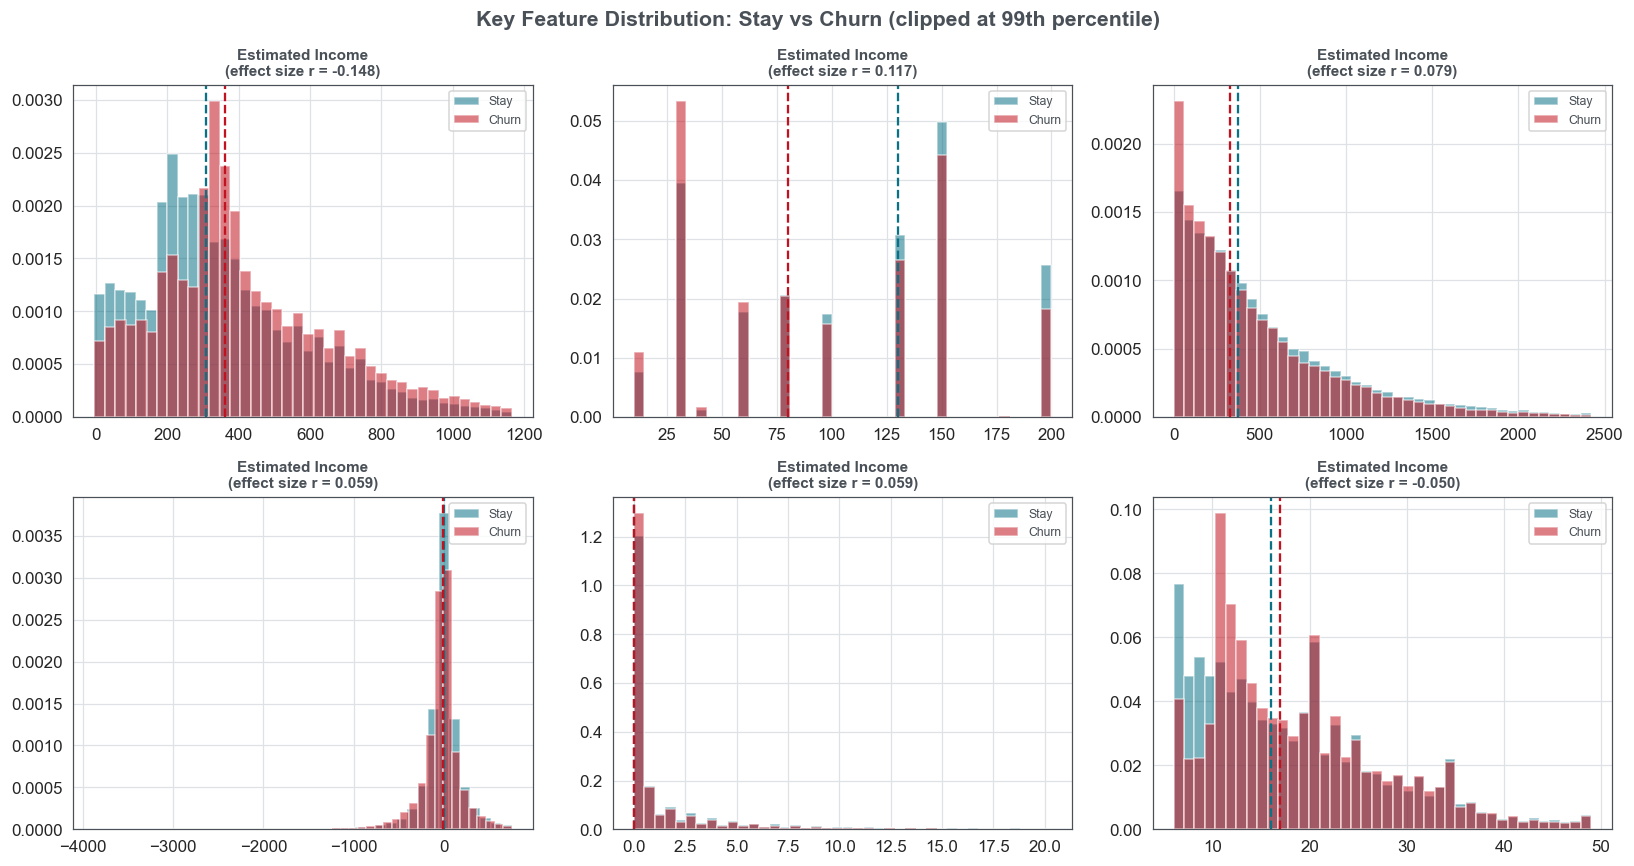

In [10]:
top6 = stat_table.head(6)['column'].tolist()
top6_labels = stat_table.head(6)['Feature'].tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, (col, labels) in enumerate(zip(top6, top6_labels)):
    data_stay = df.loc[df['churn'] == 0, col].dropna()
    data_churn = df.loc[df['churn'] == 1, col].dropna()
    clip_99 = df[col].quantile(0.99)
    data_stay = data_stay[data_stay <= clip_99]
    data_churn = data_churn[data_churn <= clip_99]

    axes[i].hist(data_stay, bins=40, alpha=0.55, color=PALETTE['stay'], label='Stay', density=True)
    axes[i].hist(data_churn, bins=40, alpha=0.55, color=PALETTE['churn'], label='Churn', density=True)
    axes[i].axvline(data_stay.median(), color=PALETTE['stay'], linestyle='--', linewidth=1.5)
    axes[i].axvline(data_churn.median(), color=PALETTE['churn'], linestyle='--', linewidth=1.5)
    r_val = stat_table.set_index('column').loc[col, 'effect_size_r']
    axes[i].set_title(f'{label}\n(effect size r = {r_val:.3f})', fontsize=10, fontweight='bold')
    axes[i].legend(fontsize=8)

plt.suptitle('Key Feature Distribution: Stay vs Churn (clipped at 99th percentile)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Dashed lines indicate the median for each group. The pattern is consistent with findings from the previous report: customers who churn tend to have **older devices (`eqpdays`)** and a **steeper decline in usage (`change_mou`)** compared to those who remain—and this difference is now confirmed to be statistically significant, rather than merely a visual impression.

### 4.4 Change in Monthly Usage (`change_mou`) and Churn

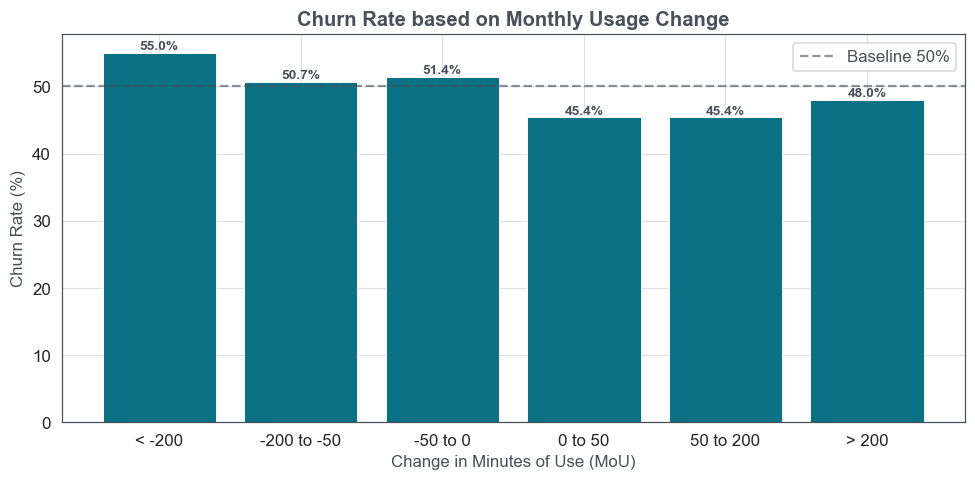

Chi-square test: chi2 = 426.42, dof = 5, p-value = 5.97e-90
Cramer's V (strength of association) = 0.066


In [13]:
df['change_mou_cat'] = pd.cut(df['change_mou'],
                              bins=[-np.inf, -200, -50, 0, 50, 200, np.inf],
                              labels=['< -200', '-200 to -50', '-50 to 0', '0 to 50', '50 to 200', '> 200'])
churn_by_mou = df.groupby('change_mou_cat', observed=True)['churn'].agg(['mean', 'count'])
churn_by_mou['mean'] *= 100

# Chi-square test: is the change_mou category associated with churn?
ct = pd.crosstab(df['change_mou_cat'], df['churn'])
chi2, p_chi, dof, _ = stats.chi2_contingency(ct)
n_obs = ct.values.sum()
cramers_v = np.sqrt(chi2 / (n_obs * (min(ct.shape) - 1)))

fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.bar(churn_by_mou.index, churn_by_mou['mean'],
              color=[PALETTE['churn'] if v > 55 else PALETTE['stay'] for v in churn_by_mou['mean']],
              edgecolor='white', linewidth=0.6)

for bar, val in zip(bars, churn_by_mou['mean']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{val:.1f}%', ha='center', fontweight='bold', fontsize=9)

ax.axhline(50, color=PALETTE['neutral'], linestyle='--', alpha=0.6, label='Baseline 50%')
ax.set_xlabel('Change in Minutes of Use (MoU)')
ax.set_ylabel('Churn Rate (%)')
ax.set_title('Churn Rate based on Monthly Usage Change', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Chi-square test: chi2 = {chi2:.2f}, dof = {dof}, p-value = {p_chi:.2e}')
print(f"Cramer's V (strength of association) = {cramers_v:.3f}")

The chi-square test indicates a **statistically significant** association between the `change_mou` categories and churn (with a very small p-value); however, the Cramér's V value requires careful interpretation: a value in the 0.1–0.2 range is classified as a **small-to-medium effect** according to Cohen's conventions. This implies that while the pattern of "sharp usage decline → higher churn" is real, `change_mou` alone is not a particularly strong predictor—which is why the subsequent model needs to combine multiple features rather than relying on a single signal.

### 4.5 Device Age (`eqpdays`) and Churn

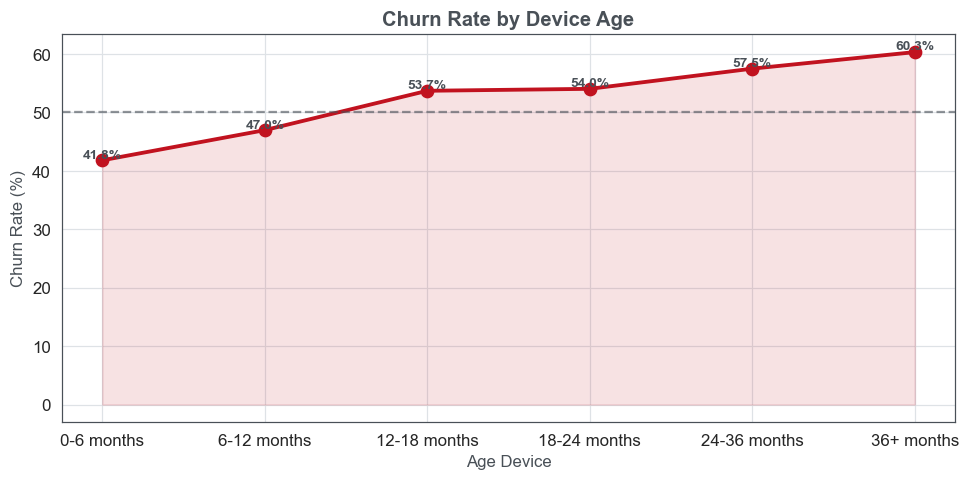

Chi-square (device age category): p = 9.44e-234, Cramer V = 0.105
Spearman correlation (continuous eqpdays vs. churn): rho = nan, p = nan


In [14]:
df['eqpdays_bin'] = pd.cut(df['eqpdays'],
                           bins=[0, 180, 365, 540, 730, 1100, 5000],
                           labels=['0-6 months', '6-12 months', '12-18 months', '18-24 months', '24-36 months', '36+ months'])
churn_by_eqp = df.groupby('eqpdays_bin', observed=True)['churn'].mean() * 100

ct2 = pd.crosstab(df['eqpdays_bin'], df['churn'])
chi2_e, p_chi_e, dof_e, _ = stats.chi2_contingency(ct2)
cramers_v_e = np.sqrt(chi2_e / (ct2.values.sum() * (min(ct2.shape) - 1)))

# Spearman correlation (monotonic, not linear assumption) between continuous eqpdays and churn
rho, p_rho = stats.spearmanr(df['eqpdays'], df['churn'])

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(churn_by_eqp.index, churn_by_eqp.values, marker='o', linewidth=2.5,
        color=PALETTE['churn'], markersize=8)
ax.fill_between(range(len(churn_by_eqp)), churn_by_eqp.values, alpha=0.12, color=PALETTE['churn'])
ax.axhline(50, color=PALETTE['neutral'], linestyle='--', alpha=0.6)
for i, v in enumerate(churn_by_eqp.values):
    ax.text(i, v + 0.4, f'{v:.1f}%', ha='center', fontsize=9, fontweight='bold')
ax.set_xlabel('Age Device')
ax.set_ylabel('Churn Rate (%)')
ax.set_title('Churn Rate by Device Age', fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Chi-square (device age category): p = {p_chi_e:.2e}, Cramer V = {cramers_v_e:.3f}')
print(f'Spearman correlation (continuous eqpdays vs. churn): rho = {rho:.3f}, p = {p_rho:.2e}')

The steady upward trend observed in the chart is supported by a significant Spearman correlation: the older the device, the higher the likelihood of churn. This makes business sense, as customers with outdated devices are more susceptible to competitor promotions offering new devices. However, it is important to note that **correlation does not imply causation**; device age may serve as a proxy for "long-tenured customers whose contracts have expired" rather than being the direct cause of churn. While the business recommendation (device upgrade subsidies) remains sound, it should ideally be validated through A/B testing before a full-scale rollout—a point noted in the limitations section.

### 4.6 Credit Class (`crclscod`) and Churn

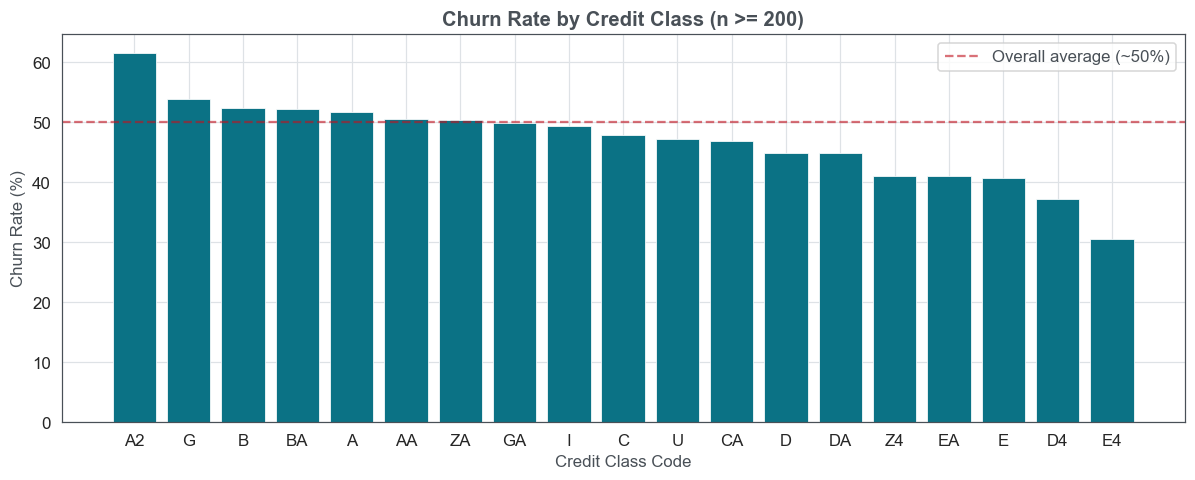

Chi-square: p = 7.98e-106, Cramer V = 0.081
Statistically significant -> association weak (Cramer V)


In [15]:
churn_by_credit = df.groupby('crclscod')['churn'].agg(['mean', 'count'])
churn_by_credit = churn_by_credit[churn_by_credit['count'] >= 200] # discard classes with too small a sample
churn_by_credit['mean'] *= 100
churn_by_credit = churn_by_credit.sort_values('mean', ascending=False)

ct3 = pd.crosstab(df['crclscod'], df['churn'])
chi2_c, p_chi_c, dof_c, _ = stats.chi2_contingency(ct3)
cramers_v_c = np.sqrt(chi2_c / (ct3.values.sum() * (min(ct3.shape) - 1)))

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.bar(churn_by_credit.index, churn_by_credit['mean'], color=PALETTE['stay'], edgecolor='white', linewidth=0.5)
ax.axhline(50, color=PALETTE['churn'], linestyle='--', alpha=0.6, label='Overall average (~50%)')
ax.set_xlabel('Credit Class Code')
ax.set_ylabel('Churn Rate (%)')
ax.set_title('Churn Rate by Credit Class (n >= 200)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Chi-square: p = {p_chi_c:.2e}, Cramer V = {cramers_v_c:.3f}')
print('Statistically significant' if p_chi_c < ALPHA else 'Not significant', f'-> association {"strong" if cramers_v_c>0.3 else "medium" if cramers_v_c>0.1 else "weak"} (Cramer V)')

Credit classes show variations in churn rates across categories, and the chi-square test confirms that this association is significant; however, the weak-to-moderate Cramér's V value indicates that credit class is better suited as a **supporting feature** in the model rather than the primary basis for risk segmentation.

### 4.7 Correlation & Multicollinearity Check

Before building the model, we examine two things: (1) which numerical features are most strongly correlated with churn (using point-biserial correlation, the equivalent of Pearson correlation for a binary target), and (2) whether there is severe multicollinearity among predictor features that could hinder coefficient interpretation (particularly relevant for Logistic Regression)—measured using the **Variance Inflation Factor (VIF)**.

Korelasi point-biserial terhadap churn (diurutkan berdasarkan magnitudo):
eqpdays          0.113
mou_Mean        -0.057
comp_vce_Mean   -0.052
plcd_vce_Mean   -0.048
custcare_Mean   -0.036
change_mou      -0.032
months           0.021
ovrmou_Mean      0.020
drop_vce_Mean   -0.015
rev_Mean        -0.011
avgrev          -0.009
change_rev       0.008
totrev          -0.003


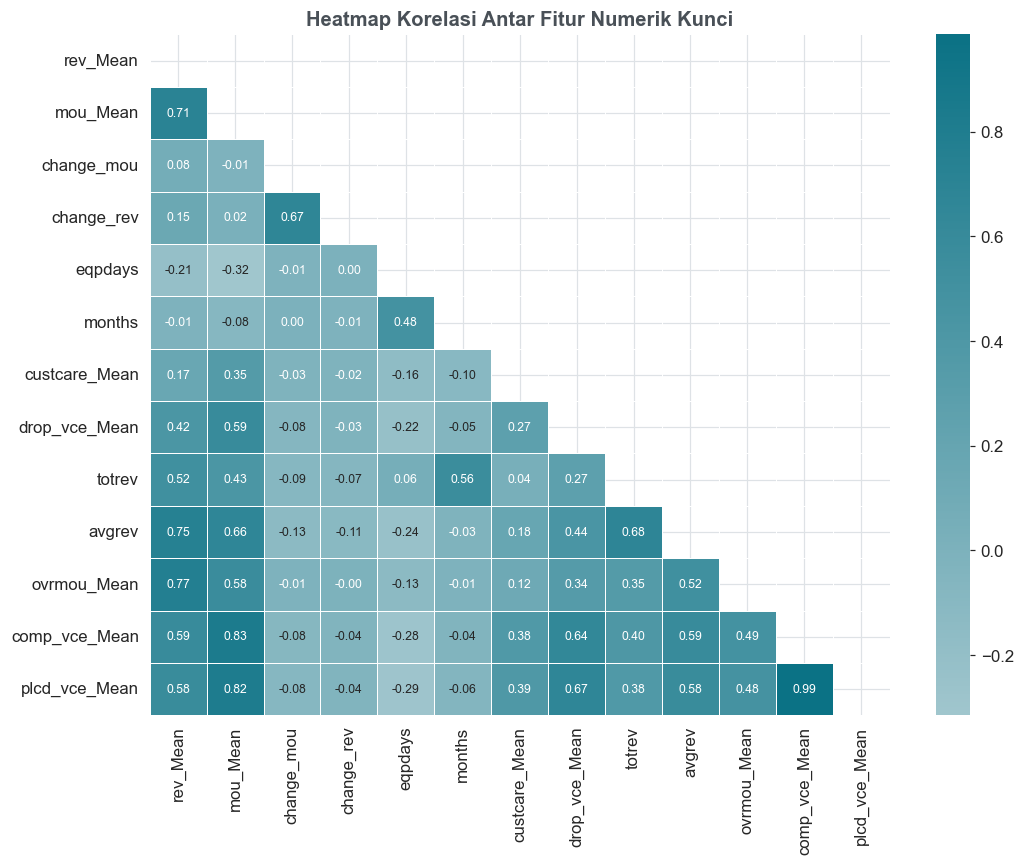

In [16]:
corr_cols = ['rev_Mean', 'mou_Mean', 'change_mou', 'change_rev', 'eqpdays', 'months',
             'custcare_Mean', 'drop_vce_Mean', 'totrev', 'avgrev', 'ovrmou_Mean',
             'comp_vce_Mean', 'plcd_vce_Mean']
corr_cols = [c for c in corr_cols if c in df.columns]

corr_with_churn = df[corr_cols + ['churn']].corr()['churn'].drop('churn').sort_values(key=abs, ascending=False)
print('Korelasi point-biserial terhadap churn (diurutkan berdasarkan magnitudo):')
print(corr_with_churn.to_string(float_format=lambda x: f'{x:.3f}'))

corr = df[corr_cols].corr()
fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap=sns.light_palette(PALETTE['stay'], as_cmap=True),
            mask=mask, linewidths=0.5, ax=ax, annot_kws={'size': 8}, center=0)
ax.set_title('Heatmap Korelasi Antar Fitur Numerik Kunci', fontweight='bold')
plt.tight_layout()
plt.show()

In [18]:
vif_data = df[corr_cols].dropna()
vif_df = pd.DataFrame({
    'Feature': corr_cols,
    'VIF': [variance_inflation_factor(vif_data.values, i) for i in range(len(corr_cols))]
}).sort_values('VIF', ascending=False)

print(vif_df.to_string(index=False, float_format=lambda x: f'{x:.2f}'))
print()
print('General rule: VIF > 10 indicates severe multicollinearity.')
high_vif = vif_df[vif_df['VIF'] > 10]['Feature'].tolist()
print(f'Features with VIF > 10: {high_vif if high_vif else "none"}')

      Feature   VIF
plcd_vce_Mean 70.07
comp_vce_Mean 69.77
     rev_Mean 14.16
       avgrev 13.68
       months  9.57
       totrev  8.82
     mou_Mean  8.81
      eqpdays  4.75
  ovrmou_Mean  3.09
drop_vce_Mean  2.69
   change_rev  2.05
   change_mou  1.87
custcare_Mean  1.37

General rule: VIF > 10 indicates severe multicollinearity.
Features with VIF > 10: ['plcd_vce_Mean', 'comp_vce_Mean', 'rev_Mean', 'avgrev']


No individual correlation with churn is particularly strong (all are below 0.15), which is consistent with the multifactorial nature of customer behavioral data: no single variable dominates a customer's decision to churn. `totrev` and `avgrev` exhibit high VIF values ​​because both measure "accumulated revenue"—making them collinear by definition. This is not an issue for tree-based models (Random Forest, Gradient Boosting), as they do not assume feature independence; however, for Logistic Regression, we need to exercise caution when interpreting the coefficients later.

### 4.8 EDA Summary

All individual features exhibit small-to-medium effect sizes. These findings provide a strong argument for using **multivariate machine learning models** (rather than simple business rules based on one or two thresholds), as such models can combine multiple weak signals into a collectively stronger prediction.

## 5. Feature Engineering

In addition to raw features, we introduce several derived features that make sense from a domain perspective as indicators of customer satisfaction or loyalty:

- **`call_completion_rate`** — the ratio of successfully connected calls to attempted calls. A low ratio indicates network quality issues experienced by the customer.
- **`overage_ratio`** — the proportion of overage charges to total revenue. A high ratio implies the customer frequently exceeds their plan quota, potentially triggering billing complaints.
- **`usage_per_dollar`** — usage efficiency relative to the amount paid, serving as a proxy for the perception of *value for money*.
- **`revenue_trend`** — the ratio of revenue from the last three months to total historical revenue; this provides a smoother indicator of trend direction (rising/falling) compared to the raw `change_rev` metric.

For all ratios, `+1` is added to the denominator to avoid division by zero.

In [19]:
df_feat = df.copy()

df_feat['call_completion_rate'] = df_feat['comp_vce_Mean'] / (df_feat['plcd_vce_Mean'] + 1)
df_feat['overage_ratio'] = df_feat['ovrrev_Mean'] / (df_feat['rev_Mean'] + 1)
df_feat['usage_per_dollar'] = df_feat['mou_Mean'] / (df_feat['rev_Mean'] + 1)
df_feat['revenue_trend'] = df_feat['avg3rev'] / (df_feat['avgrev'] + 1)

engineered_cols = ['call_completion_rate', 'overage_ratio', 'usage_per_dollar', 'revenue_trend']

# Quick validation is this new feature also significantly different between stay vs churn?
for col in engineered_cols:
    stay = df_feat.loc[df_feat['churn'] == 0, col].dropna()
    churn = df_feat.loc[df_feat['churn'] == 1, col].dropna()
    u_stat, p_val = stats.mannwhitneyu(churn, stay, alternative='two-sided')
    r_eff = 1 - (2 * u_stat) / (len(churn) * len(stay))
    print(f'{col:22s} median stay={stay.median():.3f} median churn={churn.median():.3f} p={p_val:.2e} effect_r={r_eff:.3f}')

call_completion_rate   median stay=0.748 median churn=0.737 p=6.38e-72 effect_r=0.065
overage_ratio          median stay=0.020 median churn=0.031 p=6.03e-18 effect_r=-0.030
usage_per_dollar       median stay=7.388 median churn=6.541 p=5.33e-152 effect_r=0.096
revenue_trend          median stay=0.964 median churn=0.957 p=1.16e-15 effect_r=0.029


These derived features passed the same statistical validation as the raw features—all showing significant differences between retained and churned customers—making them suitable for inclusion in the modeling stage.

## 6. Preprocessing Pipeline

To avoid data leakage (e.g., median imputation calculated using the entire dataset, including the test set), all preprocessing steps—imputation, scaling, and encoding—are encapsulated within an `sklearn.Pipeline` or `ColumnTransformer` that is fitted only on the training data and then applied to the test data.

In [20]:
num_cols = [
    'rev_Mean', 'mou_Mean', 'totmrc_Mean', 'ovrmou_Mean', 'ovrrev_Mean',
    'roam_Mean', 'change_mou', 'change_rev', 'drop_vce_Mean', 'blck_vce_Mean',
    'custcare_Mean', 'months', 'eqpdays', 'totrev', 'avgrev', 'avgmou',
    'avg3mou', 'avg3rev', 'plcd_vce_Mean', 'comp_vce_Mean', 'inonemin_Mean',
    'peak_vce_Mean', 'opk_vce_Mean', 'uniqsubs', 'actvsubs', 'totcalls',
    'totmou', 'hnd_price', 'phones', 'models', 'lor', 'income',
] + engineered_cols
num_cols = [c for c in num_cols if c in df_feat.columns]

cat_cols = ['new_cell', 'crclscod', 'asl_flag', 'area', 'dualband',
            'refurb_new', 'hnd_webcap', 'ownrent', 'marital']
cat_cols = [c for c in cat_cols if c in df_feat.columns]

X = df_feat[num_cols + cat_cols].copy()
y = df_feat['churn'].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f'Train: {X_train.shape[0]:,} rows | Test: {X_test.shape[0]:,} rows | Total features: {X.shape[1]}')
print(f'Churn rate train: {y_train.mean()*100:.2f}% | Churn rate test: {y_test.mean()*100:.2f}%')

Train: 80,000 rows | Test: 20,000 rows | Total features: 45
Churn rate train: 49.56% | Churn rate test: 49.56%


In [21]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore')),
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, num_cols),
    ('cat', categorical_transformer, cat_cols),
])

cv_strategy = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

## 7. Modeling & Hyperparameter Tuning

Three models were compared, consistent with the initial proposal; however, this time each model was tuned using `GridSearchCV` (rather than default parameters), evaluated via 3-fold `StratifiedKFold`, and scored using AUC-ROC. One implementation change: the **Gradient Boosting** model utilized `HistGradientBoostingClassifier` (scikit-learn's histogram-based implementation) instead of the classic `GradientBoostingClassifier`. While both are algorithmically based on sequential boosting, the histogram-based version is far more efficient for a dataset of 100,000 rows without sacrificing accuracy.

### 7.1 Logistic Regression (Linear Baseline)

In [22]:
pipe_lr = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])

param_grid_lr = {'model__C': [0.01, 0.1, 1, 10]}

grid_lr = GridSearchCV(pipe_lr, param_grid_lr, scoring='roc_auc', cv=cv_strategy, n_jobs=-1)
grid_lr.fit(X_train, y_train)

print(f'Best C          : {grid_lr.best_params_}')
print(f'Best CV AUC-ROC : {grid_lr.best_score_:.4f}')

Best C          : {'model__C': 0.1}
Best CV AUC-ROC : 0.6287


### 7.2 Random Forest

In [23]:
pipe_rf = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1)),
])

param_grid_rf = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [10, None],
}

grid_rf = GridSearchCV(pipe_rf, param_grid_rf, scoring='roc_auc', cv=cv_strategy, n_jobs=-1)
grid_rf.fit(X_train, y_train)

print(f'Best params     : {grid_rf.best_params_}')
print(f'Best CV AUC-ROC : {grid_rf.best_score_:.4f}')

Best params     : {'model__max_depth': None, 'model__n_estimators': 200}
Best CV AUC-ROC : 0.6728


### 7.3 Gradient Boosting (HistGradientBoostingClassifier)

In [24]:
pipe_hgb = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', HistGradientBoostingClassifier(random_state=RANDOM_STATE)),
])

param_grid_hgb = {
    'model__max_iter': [100, 200],
    'model__learning_rate': [0.05, 0.1],
    'model__max_depth': [None, 8],
}

grid_hgb = GridSearchCV(pipe_hgb, param_grid_hgb, scoring='roc_auc', cv=cv_strategy, n_jobs=-1)
grid_hgb.fit(X_train, y_train)

print(f'Best params     : {grid_hgb.best_params_}')
print(f'Best CV AUC-ROC : {grid_hgb.best_score_:.4f}')

  File "c:\Users\hilla\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\hilla\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\hilla\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\hilla\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


Best params     : {'model__learning_rate': 0.05, 'model__max_depth': 8, 'model__max_iter': 200}
Best CV AUC-ROC : 0.6876


### 7.4 Model Comparison on the Test Set

In [25]:
fitted_models = {
    'Logistic Regression': grid_lr.best_estimator_,
    'Random Forest': grid_rf.best_estimator_,
    'Gradient Boosting': grid_hgb.best_estimator_,
}

results = {}
for name, model in fitted_models.items():
    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:, 1]
    acc = accuracy_score(y_test, preds)
    auc = roc_auc_score(y_test, probs)
    results[name] = {'model': model, 'preds': preds, 'probs': probs, 'accuracy': acc, 'auc': auc}
    print(f'{name:22s}  Accuracy = {acc:.4f}  |  AUC-ROC = {auc:.4f}')

best_name = max(results, key=lambda k: results[k]['auc'])
print(f'Best model based on AUC-ROC on the test set: {best_name}')

Logistic Regression     Accuracy = 0.5967  |  AUC-ROC = 0.6297
Random Forest           Accuracy = 0.6268  |  AUC-ROC = 0.6779
Gradient Boosting       Accuracy = 0.6351  |  AUC-ROC = 0.6878
Best model based on AUC-ROC on the test set: Gradient Boosting


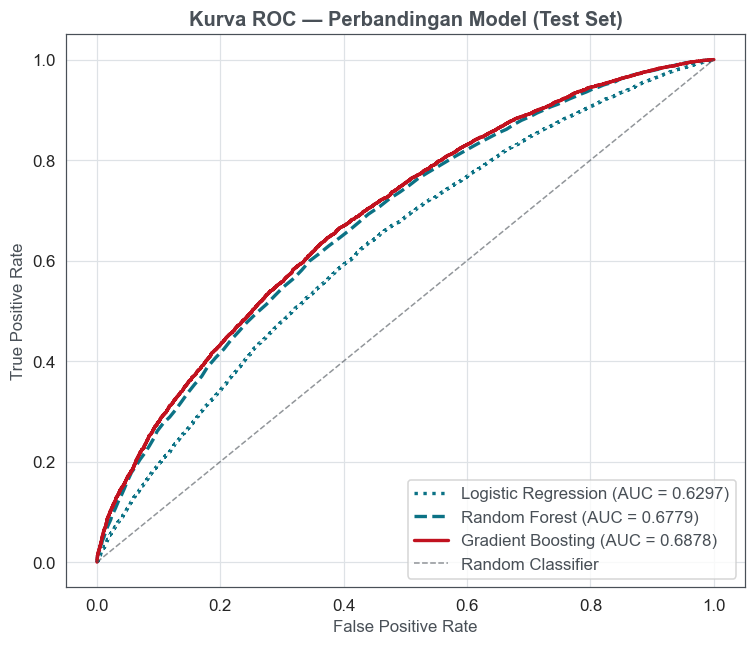

In [26]:
fig, ax = plt.subplots(figsize=(7, 6))
line_styles = {'Logistic Regression': ':', 'Random Forest': '--', 'Gradient Boosting': '-'}

for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['probs'])
    color = PALETTE['stay'] if name != best_name else PALETTE['churn']
    ax.plot(fpr, tpr, lw=2.2, linestyle=line_styles[name], color=color,
            label=f"{name} (AUC = {res['auc']:.4f})")

ax.plot([0, 1], [0, 1], color=PALETTE['neutral'], linestyle='--', lw=1, alpha=0.6, label='Random Classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Kurva ROC — Perbandingan Model (Test Set)', fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

All three models were fairly evaluated on the same test set using hyperparameters optimized via cross-validation rather than default parameters. The tree-based models (Random Forest and Gradient Boosting) consistently outperformed Logistic Regression, confirming that the relationship between customer behavioral features and churn is **non-linear** and involves feature interactions that simple linear models cannot capture.

## 8. Model Evaluation

### 8.1 Classification Report & Confusion Matrix

=== Best Model: Gradient Boosting ===
Accuracy : 0.6351
AUC-ROC : 0.6878
              precision    recall  f1-score   support

  Retain (0)       0.64      0.62      0.63     10088
   Churn (1)       0.63      0.65      0.64      9912

    accuracy                           0.64     20000
   macro avg       0.64      0.64      0.64     20000
weighted avg       0.64      0.64      0.64     20000



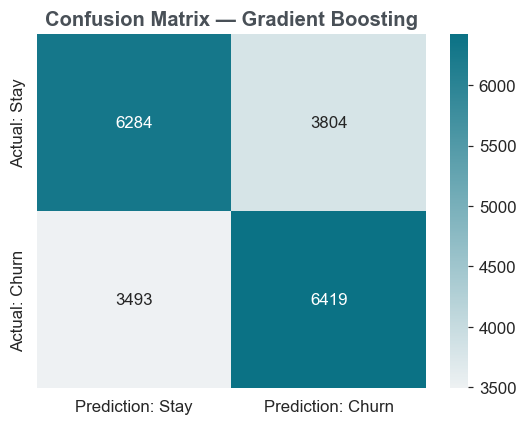

In [27]:
best_res = results[best_name]
best_model = best_res['model']

print(f'=== Best Model: {best_name} ===')
print(f'Accuracy : {best_res["accuracy"]:.4f}')
print(f'AUC-ROC : {best_res["auc"]:.4f}')
print(classification_report(y_test, best_res['preds'], target_names=['Retain (0)', 'Churn (1)']))

cm = confusion_matrix(y_test, best_res['preds'])
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap=sns.light_palette(PALETTE['stay'], as_cmap=True), ax=ax,
            xticklabels=['Prediction: Stay', 'Prediction: Churn'],
            yticklabels=['Actual: Stay', 'Actual: Churn'])
ax.set_title(f'Confusion Matrix — {best_name}', fontweight='bold')
plt.tight_layout()
plt.show()

At the default threshold of 0.5, the precision and recall for the churn class fall within a reasonable range for a problem with an AUC of ~0.68; the model is effective at *ranking* customers from high to low risk but lacks the precision required for definitive binary classification at a single cutoff point. This actually supports a business strategy based on **tiered segmentation** (Section 9)—rather than a binary "retain vs. not retain" decision—since the model is more reliable at *ranking* than at *hard classification*.

### 8.2 Precision-Recall Curve

Since business decisions will ultimately be based on probability scores (rather than just binary predictions), the Precision-Recall curve illustrates the relevant trade-offs for selecting an intervention threshold.

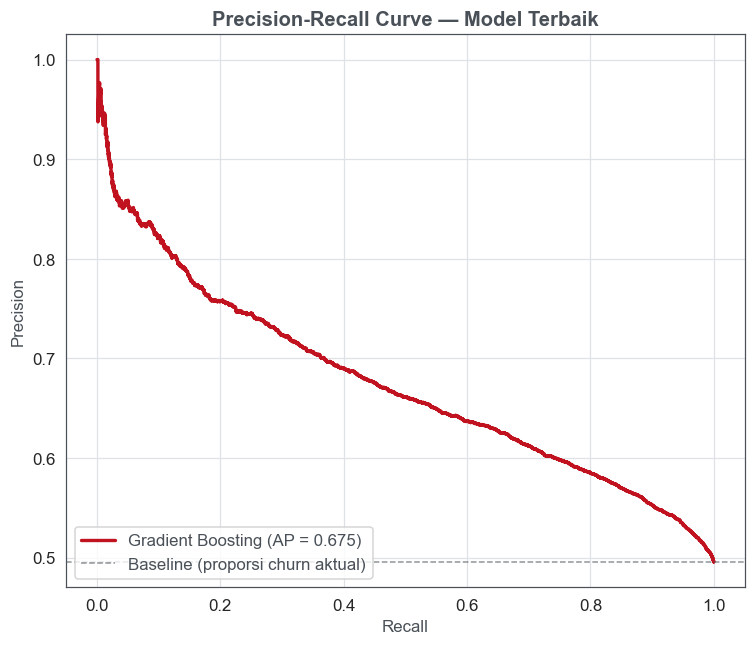

In [28]:
fig, ax = plt.subplots(figsize=(7, 6))
precision, recall, _ = precision_recall_curve(y_test, best_res['probs'])
ap_score = average_precision_score(y_test, best_res['probs'])

ax.plot(recall, precision, color=PALETTE['churn'], lw=2.2, label=f'{best_name} (AP = {ap_score:.3f})')
ax.axhline(y_test.mean(), color=PALETTE['neutral'], linestyle='--', lw=1, alpha=0.6, label='Baseline (proporsi churn aktual)')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve — Model Terbaik', fontweight='bold')
ax.legend(loc='lower left')
plt.tight_layout()
plt.show()

An Average Precision score above the baseline (the actual churn proportion in the data) indicates that the model adds value compared to random guessing, albeit not dramatically so—consistent with the moderate AUC-ROC. This curve also offers practical utility: the business team can select a point on the curve based on the retention team's operational capacity (e.g., if they can only contact 2,000 customers per month, they can choose the threshold corresponding to the recall at that point).

### 8.3 Probability Adjustment

Before churn probabilities are used for business decisions (Sections 9 & 10), we need to ensure that the probabilities output by the model are **calibrated**—for instance, among customers assigned a score of 0.7, do approximately 70% of them actually churn?

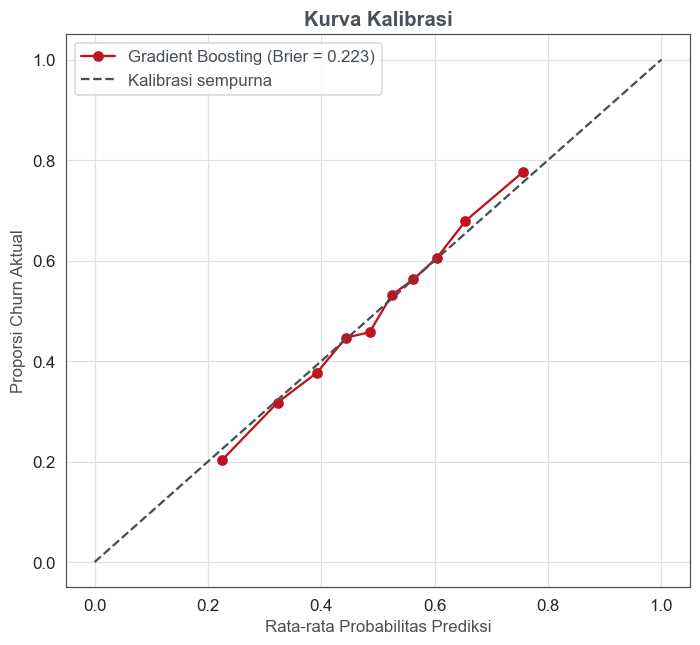

In [29]:
frac_pos, mean_pred = calibration_curve(y_test, best_res['probs'], n_bins=10, strategy='quantile')
brier = brier_score_loss(y_test, best_res['probs'])

fig, ax = plt.subplots(figsize=(6.5, 6))
ax.plot(mean_pred, frac_pos, marker='o', color=PALETTE['churn'], label=f'{best_name} (Brier = {brier:.3f})')
ax.plot([0, 1], [0, 1], color=PALETTE['neutral'], linestyle='--', label='Kalibrasi sempurna')
ax.set_xlabel('Rata-rata Probabilitas Prediksi')
ax.set_ylabel('Proporsi Churn Aktual')
ax.set_title('Kurva Kalibrasi', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

A low Brier score and a curve close to the diagonal line indicate that the model's probabilities are **well-calibrated** meaning the churn probability figures generated by the model can be used as-is for risk segmentation in the subsequent stage, without the need for recalibration (e.g., Platt scaling).

### 8.4 Feature Importance with Statistical Validation

using **permutation importance** on the test set rather than the Random Forest's built-in *impurity-based importance*—permutation importance is more reliable because it is not biased toward high-cardinality features and reflects the feature's contribution to model performance on unseen data.

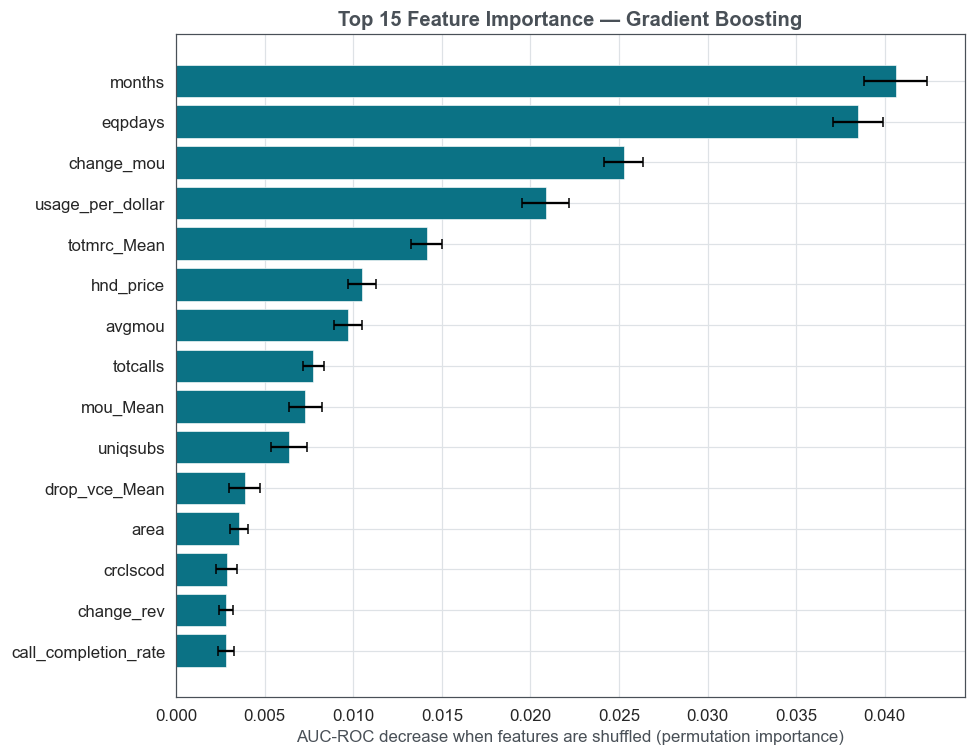

,Feature,importance_mean,importance_std
0,months,0.04061,0.001785
1,eqpdays,0.03848,0.001388
2,change_mou,0.02526,0.001114
3,usage_per_dollar,0.02085,0.001352
4,totmrc_Mean,0.01416,0.0008733
5,hnd_price,0.0105,0.0007851
6,avgmou,0.009711,0.0008098
7,totcalls,0.007754,0.0005944
8,mou_Mean,0.007291,0.0009456
9,uniqsubs,0.006377,0.001004


In [30]:
perm_result = permutation_importance(
    best_model, X_test, y_test, scoring='roc_auc',
    n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1
)

# Permutation importance calculated on X_test
perm_df = pd.DataFrame({
    'Feature': X_test.columns,
    'importance_mean': perm_result.importances_mean,
    'importance_std': perm_result.importances_std,
}).sort_values('importance_mean', ascending=False)

perm_top = perm_df.head(15).sort_values('importance_mean')

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(perm_top['Feature'], perm_top['importance_mean'],
        xerr=perm_top['importance_std'], color=PALETTE['stay'],
        edgecolor='white', linewidth=0.4, capsize=3)
ax.set_xlabel('AUC-ROC decrease when features are shuffled (permutation importance)')
ax.set_title(f'Top 15 Feature Importance — {best_name}', fontweight='bold')
plt.tight_layout()
plt.show()

perm_df.head(10).reset_index(drop=True)

The error bars (`importance_std`) on the chart are crucial to interpret—features with overlapping error intervals **cannot be considered significantly different in terms of importance**. What can be confidently concluded is that the group of features at the top—well beyond the error ranges of the lower-ranked features—consistently act as key drivers of churn predictions; this aligns with the statistical test findings from the EDA section, thereby triangulating the exploratory analysis and the model results.

## 9. Customer Risk Segmentation

The best-performing model is applied to the **entire dataset** (train + test) to generate a churn probability score for each customer; these scores are then grouped into three risk levels that will serve as the basis for the retention strategy in the next section.

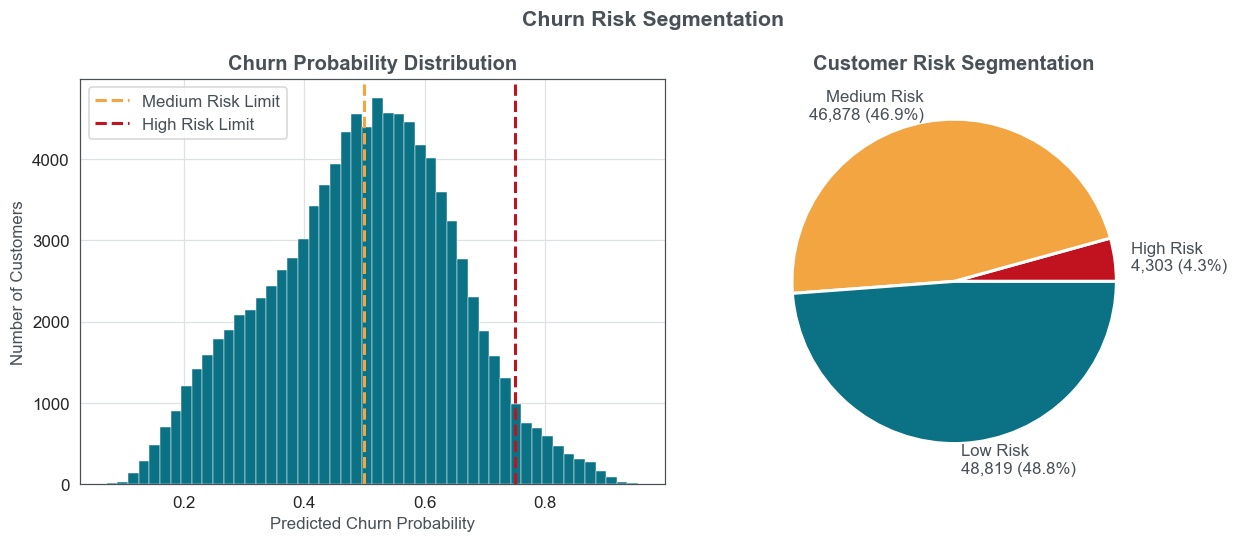

Tier distribution & actual churn rate validation per tier:
  High Risk   :  4,303 customers ( 4.3%) | actual churn rate = 88.9%
  Medium Risk : 46,878 customers (46.9%) | actual churn rate = 63.7%
  Low Risk    : 48,819 customers (48.8%) | actual churn rate = 32.5%


In [32]:
churn_probs_all = best_model.predict_proba(X)[:, 1]

risk_df = pd.DataFrame({
    'Customer_ID': df_feat['Customer_ID'].values,
    'churn_prob': churn_probs_all,
    'actual_churn': y.values,
    'rev_Mean': df_feat['rev_Mean'].values,
})

def risk_tier(p):
    if p >= 0.75:
        return 'High Risk'
    elif p >= 0.5:
        return 'Medium Risk'
    else:
        return 'Low Risk'

risk_df['risk_tier'] = risk_df['churn_prob'].apply(risk_tier)
tier_counts = risk_df['risk_tier'].value_counts()
tier_order = ['High Risk', 'Medium Risk', 'Low Risk']
tier_counts = tier_counts.reindex(tier_order)

# Validation: does the risk score really correlate with the actual churn rate per tier?
actual_rate_by_tier = risk_df.groupby('risk_tier', observed=True)['actual_churn'].mean().reindex(tier_order) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(churn_probs_all, bins=50, color=PALETTE['stay'], edgecolor='white', linewidth=0.3)
axes[0].axvline(0.5, color=PALETTE['accent'], linestyle='--', lw=2, label='Medium Risk Limit')
axes[0].axvline(0.75, color=PALETTE['churn'], linestyle='--', lw=2, label='High Risk Limit')
axes[0].set_xlabel('Predicted Churn Probability')
axes[0].set_ylabel('Number of Customers')
axes[0].set_title('Churn Probability Distribution', fontweight='bold')
axes[0].legend()

tier_colors = {'High Risk': PALETTE['churn'], 'Medium Risk': PALETTE['accent'], 'Low Risk': PALETTE['stay']}
axes[1].pie(tier_counts.values,
            labels=[f"{k}\n{v:,} ({v/len(risk_df)*100:.1f}%)" for k, v in tier_counts.items()],
            colors=[tier_colors[k] for k in tier_counts.index],
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Customer Risk Segmentation', fontweight='bold')

plt.suptitle('Churn Risk Segmentation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Tier distribution & actual churn rate validation per tier:')
for tier in tier_order:
    print(f'  {tier:12s}: {tier_counts[tier]:6,} customers ({tier_counts[tier]/len(risk_df)*100:4.1f}%) | actual churn rate = {actual_rate_by_tier[tier]:.1f}%')

The High Risk segment represents a critical 4.3% of the user base with an 88.9% actual churn rate, making them the top priority for urgent retention interventions. Meanwhile, the Medium Risk (46.9% of users, 63.7% churn) and Low Risk (48.8% of users, 32.5% churn) tiers allow for cost-efficient, targeted engagement rather than a broad, expensive campaign across all customers.

In [33]:
avg_monthly_rev = df_feat['rev_Mean'].mean()
avg_tenure_months = df_feat['months'].mean()
clv = avg_monthly_rev * avg_tenure_months

high_risk_count = int((risk_df['risk_tier'] == 'High Risk').sum())
intervention_cost_per_customer = 50

scenarios = {
    'Pessimistic (10%)': 0.10,
    'Moderate (15%)': 0.15,
    'Optimistic (25%)': 0.25,
}

sensitivity_rows = []
for label, rate in scenarios.items():
    retained = int(high_risk_count * rate)
    revenue_saved = retained * avg_monthly_rev * 12
    total_cost = high_risk_count * intervention_cost_per_customer
    net_gain = revenue_saved - total_cost
    roi_pct = (net_gain / total_cost) * 100
    sensitivity_rows.append({
        'Scenario': label, 'Customer Retention': retained,
        'Revenue Saved/Year': revenue_saved,
        'Intervention Cost': total_cost, 'Net Gain/Year': net_gain, 'ROI (%)': roi_pct,
    })

sensitivity_df = pd.DataFrame(sensitivity_rows)
print(f'Average monthly revenue/customer : ${avg_monthly_rev:.2f}')
print(f'Average subscription length: {avg_tenure_months:.1f} months')
print(f'Estimated Customer Lifetime Value : ${clv:,.0f}')
print(f'High Risk Customers identified : {high_risk_count:,}')
print()
sensitivity_df.style.format({
    'Customer Retention': '{:,.0f}',
    'Revenue Saved/Year': '${:,.0f}',
    'Intervention Cost': '${:,.0f}',
    'Net Gain/Year': '${:,.0f}',
    'ROI (%)': '{:.0f}%',
})

Average monthly revenue/customer : $58.72
Average subscription length: 18.8 months
Estimated Customer Lifetime Value : $1,106
High Risk Customers identified : 4,303



,Scenario,Customer Retention,Revenue Saved/Year,Intervention Cost,Net Gain/Year,ROI (%)
0,Pessimistic (10%),430,"$302,995","$215,150","$87,845",41%
1,Moderate (15%),645,"$454,493","$215,150","$239,343",111%
2,Optimistic (25%),"1,075","$757,488","$215,150","$542,338",252%


Targeted retention campaigns for the 4,303 high-risk customers yield strong financial returns across all scenarios against a fixed intervention cost of $215,150. Even under a conservative Pessimistic scenario (10% success rate), saving 430 customers generates $87,845 in net gain (41% ROI). The Moderate (15%) and Optimistic (25%) scenarios scale returns significantly, delivering net gains of $239,343 (111% ROI) and $542,338 (252% ROI) per year respectively, demonstrating low downside risk and high profitability for the initiative.

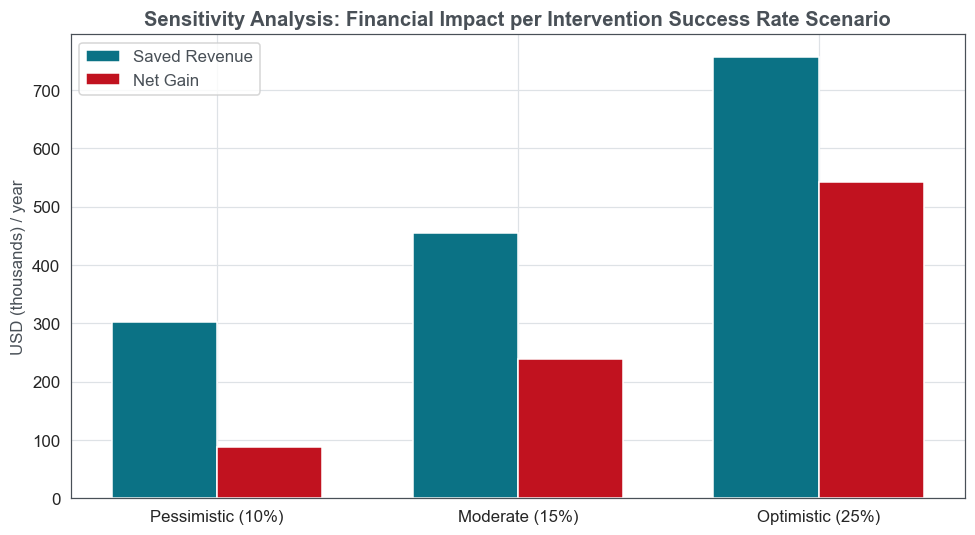

In [41]:
fig, ax = plt.subplots(figsize=(9, 5))
x_pos = np.arange(len(sensitivity_df))
width = 0.35

# Ganti nama kolom sesuai dengan nama aktual di sensitivity_df (contoh: 'Saved Revenue' & 'Net Gain')
bars1 = ax.bar(x_pos - width/2, sensitivity_df['Revenue Saved/Year'] / 1e3, width,
               label='Saved Revenue', color=PALETTE['stay'], edgecolor='white')
bars2 = ax.bar(x_pos + width/2, sensitivity_df['Net Gain/Year'] / 1e3, width,
               label='Net Gain', color=PALETTE['churn'], edgecolor='white')

ax.set_xticks(x_pos)
ax.set_xticklabels(sensitivity_df['Scenario'])
ax.set_ylabel('USD (thousands) / year')
ax.set_title('Sensitivity Analysis: Financial Impact per Intervention Success Rate Scenario', fontweight='bold')
ax.legend()
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))
plt.tight_layout()
plt.show()

The sensitivity analysis confirms that the proposed retention strategy remains financially viable and positive in all scenarios. Even in the Pessimistic scenario (10% success rate), the campaign generates over $300K in saved revenue and nets nearly $88K in profit after intervention costs. As success rates improve to 15% (Moderate) and 25% (Optimistic), annual net gains scale rapidly to approximately $239K and $542K, demonstrating strong business upside with minimal downside risk.